# 03 · Environmental variation and PCA

## Context and contents

The supplied chapters link wetland carbon pools with water and soil conditions.
This notebook first shows each measured environmental variable, then uses separate
water and soil PCAs to summarise the joint variation. PCA is descriptive and does
not use carbon stock as a response variable.

**Contents:** (1) verify the 80 records per compartment; (2) inspect seasonal
distributions; (3) standardise and compute PCA; (4) read explained variance, scores
and correlation loadings; (5) state the supported conclusions.

`PCA.xlsx` contains 13 water variables and 7 soil variables. The soil PCA includes
SOC, which is distinct from soil carbon stock. All measured columns are retained;
wetland, year, season and site are identifiers and are excluded from PCA inputs.

Run from top to bottom with **Python (ler)**. Keep the three Excel files and
`ecological_data.py` beside this notebook. Every plot is saved in `figures/a4/`
as a vector PDF and a 300-dpi PNG, **160 mm wide**. Labels are 9.5–12 pt at that
printed width. Use the figures at full text width, not as half-width thumbnails.
The source spreadsheets are unchanged; numerical tables are in `tables/`.

## Reading the plots

The sampling structure is 2 lakes × 2 years × 4 seasons × 5 sites = **80 records**
per sheet. Repeated records at the same site are not independent spatial replicates.
The numeric codes are checked against named measurement blocks in `Scatter Plot.xlsx`.

Distribution plots use separate vertical scales for different variables, with two
variables stacked per figure. Boxes pool the two years (10 records per lake–season);
point shapes distinguish 2022 and 2023. Broad boxes may therefore include a year
difference, not just variation among sites. All points, including points beyond
the whiskers, are shown.

PCA centres each raw variable and divides it by its sample SD. No log transformation,
imputation, outlier removal or variable selection is applied. Linear plot axes are
used here; the crowding is addressed by layout and grouping. Units missing from the
measurement headings are not inferred.

In [1]:
FIGURE_GROUP = "03_environment_pca"

from pathlib import Path
import json
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from IPython.display import display
from ecological_data import (
    ROOT, KEYS, SEASONS, WETLANDS, load_scatter, load_pca,
    decode_pca, load_line_summary, load_heatmaps,
)

FIG_DIR = ROOT / "figures" / "a4" / FIGURE_GROUP
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR = ROOT / "tables"
TABLE_DIR.mkdir(exist_ok=True)
# A4 with 25-mm left/right margins: 160 mm available for a figure.
WIDTH = 160 / 25.4  # inches; figures should be placed at this width in the thesis
FIGURES = []
# A4 with 25-mm left/right margins: 160 mm available for a figure.
WIDTH = 160 / 25.4  # inches; figures should be placed at this width in the thesis
FIGURES = []
sns.set_theme(style="ticks", context="notebook", font="DejaVu Sans", rc={
    "font.size": 11, "axes.labelsize": 11, "axes.titlesize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.fontsize": 10, "legend.title_fontsize": 10,
    "figure.dpi": 130, "savefig.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False, "pdf.fonttype": 42,
})
PALETTE = dict(zip(WETLANDS, sns.color_palette("colorblind", 2)))
MARKERS = dict(zip(SEASONS, ["o", "s", "^", "D"]))
LABELS = {
    "Soil_stock": r"Soil carbon stock (Mg C ha$^{-1}$)",
    "Phyto_carbon": "Phytoplankton carbon\n(unit not supplied)",
    "TBC": "Total biomass carbon\n(unit unconfirmed)",
    "Soil_Temp": "Soil temperature", "Water_Temp": "Water temperature",
    "Soil_pH": "Soil pH", "Water_pH": "Water pH", "BD": "Bulk density",
    "Moisture": "Soil moisture", "SOC": "Soil organic carbon (SOC)",
    "N": "Available nitrogen", "P": "Available phosphorus", "K": "Available potassium",
    "TDS": "Total dissolved solids (TDS)", "EC": "Electrical conductivity (EC)",
    "CO2": r"Free CO$_2$", "Turbidity": "Turbidity", "DO": "Dissolved oxygen (DO)",
    "BOD": "Biochemical oxygen demand", "COD": "Chemical oxygen demand",
    "Alkalinity": "Alkalinity", "Hardness": "Total hardness",
    "Water_K": "Water potassium", "Inorg_P": "Inorganic phosphorus",
}


SEASON_TICKS = ["Pre-\nmonsoon", "Monsoon", "Post-\nmonsoon", "Winter"]

def lake_handles(shape_by_lake=False):
    return [Line2D([], [], color=PALETTE[w], marker="s" if shape_by_lake and w == "Pumlen" else "o",
                   linestyle="", label=w, markersize=5) for w in WETLANDS]

def season_handles():
    return [Line2D([], [], color="0.2", marker=MARKERS[s], linestyle="",
                   label=s, markersize=5) for s in SEASONS]


SEASON_TICKS = ["Pre-\nmonsoon", "Monsoon", "Post-\nmonsoon", "Winter"]

def lake_handles(shape_by_lake=False):
    return [Line2D([], [], color=PALETTE[w], marker="s" if shape_by_lake and w == "Pumlen" else "o",
                   linestyle="", label=w, markersize=5) for w in WETLANDS]

def season_handles():
    return [Line2D([], [], color="0.2", marker=MARKERS[s], linestyle="",
                   label=s, markersize=5) for s in SEASONS]

def save_show(fig, name, caption):
    """Export at a fixed physical width; captions also accompany the A4 proof PDF."""
    assert np.isclose(fig.get_figwidth(), WIDTH)
    assert fig.get_figheight() <= 8.4  # leave room for a caption on A4
    # Do not use bbox_inches='tight': it changes the physical page dimensions.
    for extension in ["png", "pdf"]:
        fig.savefig(FIG_DIR / f"{name}.{extension}", facecolor="white")
    FIGURES.append({"file":name, "caption":caption})
    (FIG_DIR / "captions.json").write_text(json.dumps(FIGURES, indent=2))
    plt.show()
    plt.close(fig)

# Use linear axes for this dataset. Optional display-only overrides never change
# the values used for correlations or PCA. Log axes do not resolve exact overlaps.
SCALE_OVERRIDES = {}
def axis_scale(values, variable):
    values = np.asarray(values, dtype=float)
    assert np.isfinite(values).all()
    choice = SCALE_OVERRIDES.get(variable, "linear")
    assert choice in {"linear", "log"}
    if choice == "log" and np.any(values <= 0):
        raise ValueError(f"Cannot use log scale for nonpositive {variable} values.")
    return choice

def set_numeric_axis(ax, axis, values, variable):
    scale = axis_scale(values, variable)
    getattr(ax, f"set_{axis}scale")(scale)
    getattr(ax, f"set_{axis}label")(LABELS.get(variable, variable) + (" [log scale]" if scale == "log" else ""))

print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | seaborn {sns.__version__}")
print(f"Figures: {FIG_DIR}")

Python 3.10.18 | pandas 2.3.0 | seaborn 0.13.2
Figures: /Users/phurailatpamhemantakumar/phd/mypackages/lyn/figures/a4/03_environment_pca


In [2]:
raw = load_pca()
frames = {name:decode_pca(frame) for name,frame in raw.items()}
scatter, _ = load_scatter()
for name, frame in frames.items():
    shared = [c for c in frame if c in scatter and c not in KEYS]
    paired = frame.merge(scatter, on=KEYS, suffixes=("_pca","_named"),validate="one_to_one")
    assert len(paired) == len(frame) == len(scatter) == 80
    for variable in shared:
        assert np.allclose(paired[variable+"_pca"],paired[variable+"_named"],rtol=0,atol=1e-10)

variables = {name:[c for c in frame if c not in KEYS] for name,frame in frames.items()}
scale_rows = []
for name,frame in frames.items():
    for variable in variables[name]:
        scale_rows.append({"Compartment":name,"Variable":variable,"Minimum":frame[variable].min(),
                           "Maximum":frame[variable].max(),"Display axis":axis_scale(frame[variable],variable)})
display(pd.DataFrame(scale_rows))
print("Missing values: 0; duplicate sampling keys: 0 in each sheet.")

,Compartment,Variable,Minimum,Maximum,Display axis
0,Water,Water_Temp,16.97,28.53,linear
1,Water,TDS,60.85,107.53,linear
2,Water,EC,104.20,179.33,linear
3,Water,Water_pH,5.85,10.01,linear
4,Water,CO2,5.10,41.86,linear
5,Water,Turbidity,4.55,34.00,linear
6,Water,DO,4.30,9.20,linear
7,Water,BOD,1.17,6.36,linear
8,Water,COD,3.37,15.84,linear
9,Water,Alkalinity,60.00,112.67,linear


Missing values: 0; duplicate sampling keys: 0 in each sheet.


## 1. Seasonal environmental distributions

Boxes show the median and quartiles; whiskers extend to the most extreme observations
within 1.5 times the interquartile range from the quartiles. Individual points retain
the measured y values. Small horizontal offsets separate sites and years within
each categorical group; they do not represent different sampling dates.

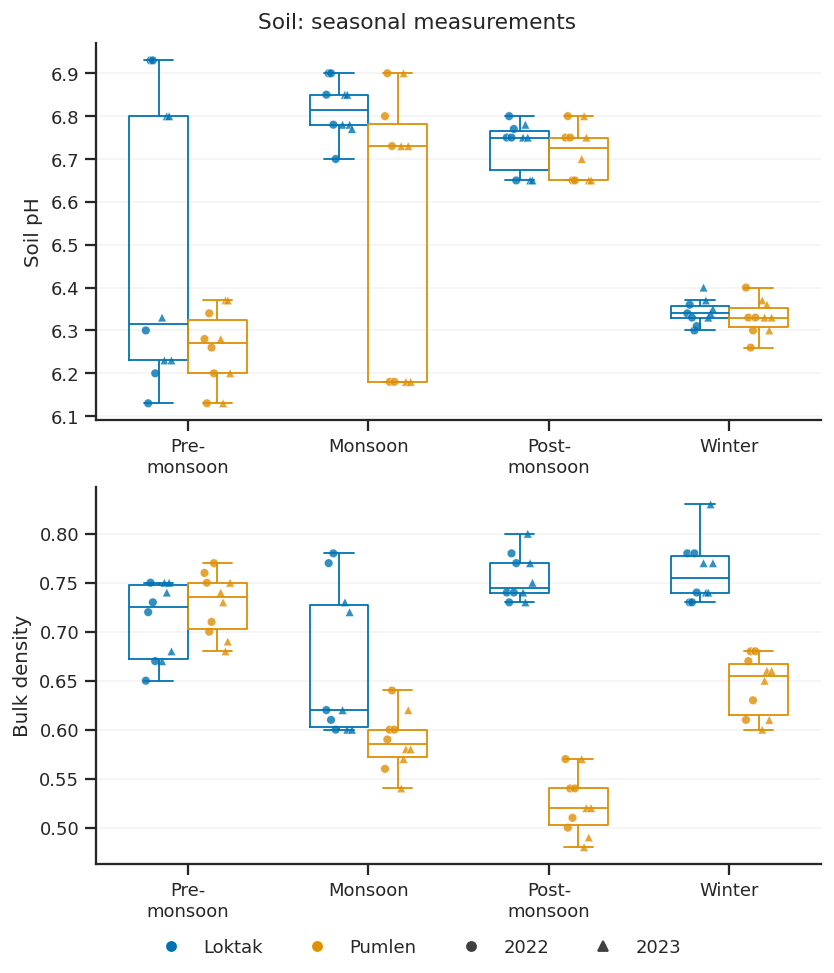

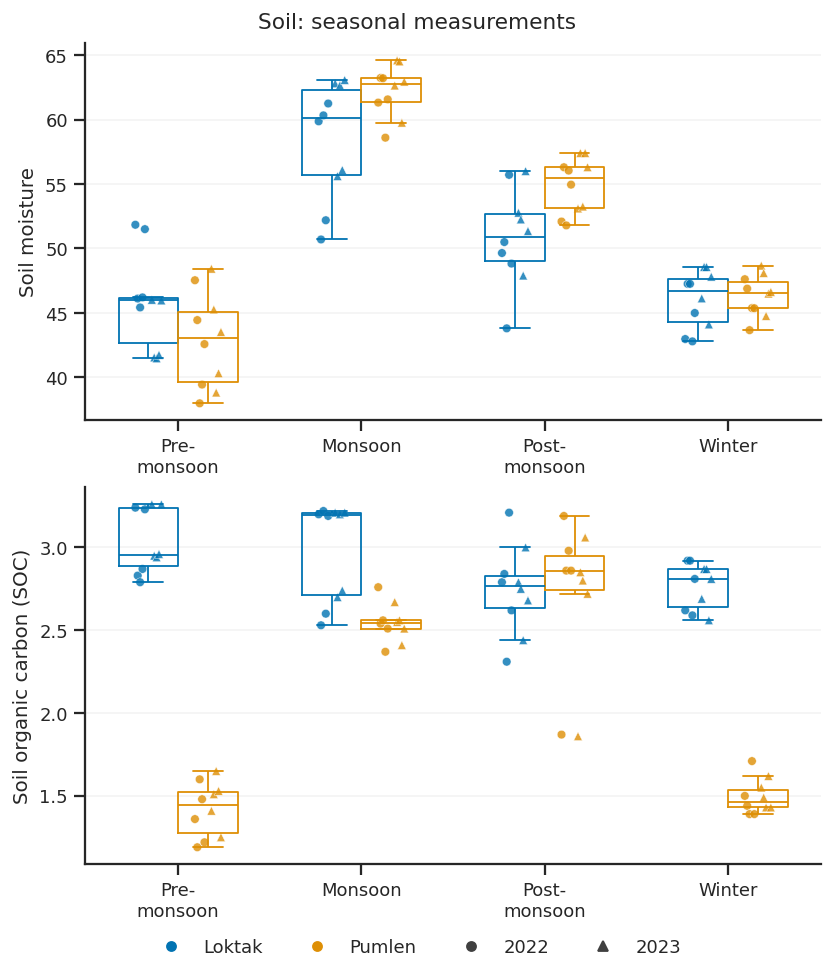

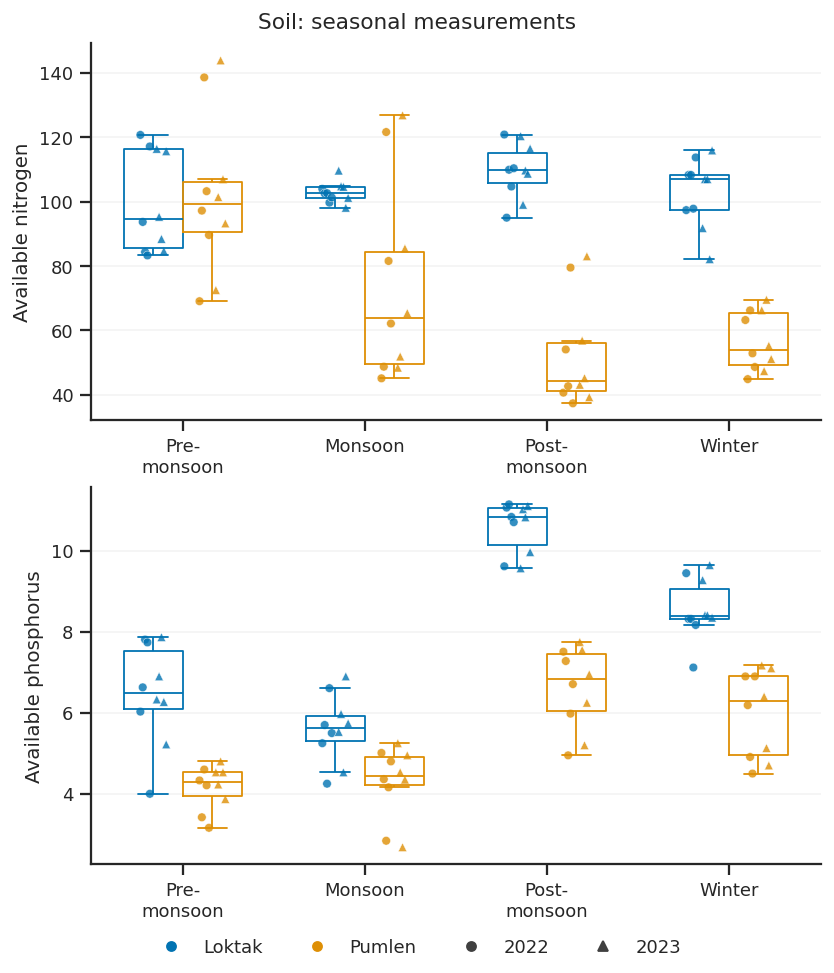

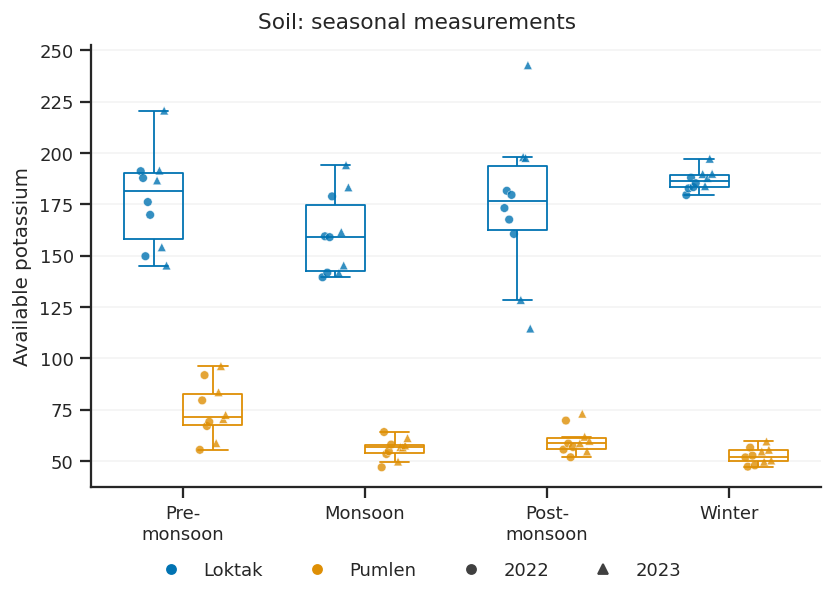

In [3]:
def distribution_page(compartment, selected, page):
    frame = frames[compartment]
    fig, axes = plt.subplots(len(selected), 1, figsize=(WIDTH, 7.4 if len(selected)==2 else 4.5),
                             squeeze=False, layout="constrained")
    for ax, variable in zip(axes.flat, selected):
        sns.boxplot(data=frame, x="Season", y=variable, hue="Wetland", order=SEASONS,
                    hue_order=WETLANDS, palette=PALETTE, showfliers=False,
                    linewidth=1.0, width=0.65, fill=False, legend=False, ax=ax)
        points = frame.copy()
        points["Position"] = (points.Season.map(dict(zip(SEASONS, range(4))))
                              + points.Wetland.map({"Loktak":-0.1625,"Pumlen":0.1625})
                              + points.Year.map({2022:-0.045,2023:0.045}) + (points.Site-3)*0.013)
        sns.scatterplot(data=points, x="Position", y=variable, hue="Wetland", style="Year",
                        hue_order=WETLANDS, style_order=[2022,2023], markers={2022:"o",2023:"^"},
                        palette=PALETTE, s=23, alpha=0.8, linewidth=0.3, edgecolor="white",
                        legend=False, ax=ax)
        set_numeric_axis(ax, "y", frame[variable], variable)
        ax.set(xlabel="", xticks=range(4), xticklabels=SEASON_TICKS)
        ax.grid(axis="y", alpha=0.2)
    handles = lake_handles() + [Line2D([],[],color="0.25",marker=m,linestyle="",label=str(y),markersize=5)
                                for y,m in [(2022,"o"),(2023,"^")]]
    fig.legend(handles=handles, loc="outside lower center", ncol=4, frameon=False)
    fig.suptitle(f"{compartment}: seasonal measurements", fontsize=12)
    save_show(fig, f"{compartment.lower()}_distributions_{page}",
              f"{compartment} measurements from PCA.xlsx. Boxes pool ten records per lake-season across two years; points show every record, with circles for 2022 and triangles for 2023. Box/whisker conventions are described in the notebook. Different variables have different y scales; units are not specified in the source headers.")

for page,start in enumerate(range(0,len(variables["Soil"]),2),1):
    distribution_page("Soil", variables["Soil"][start:start+2], page)

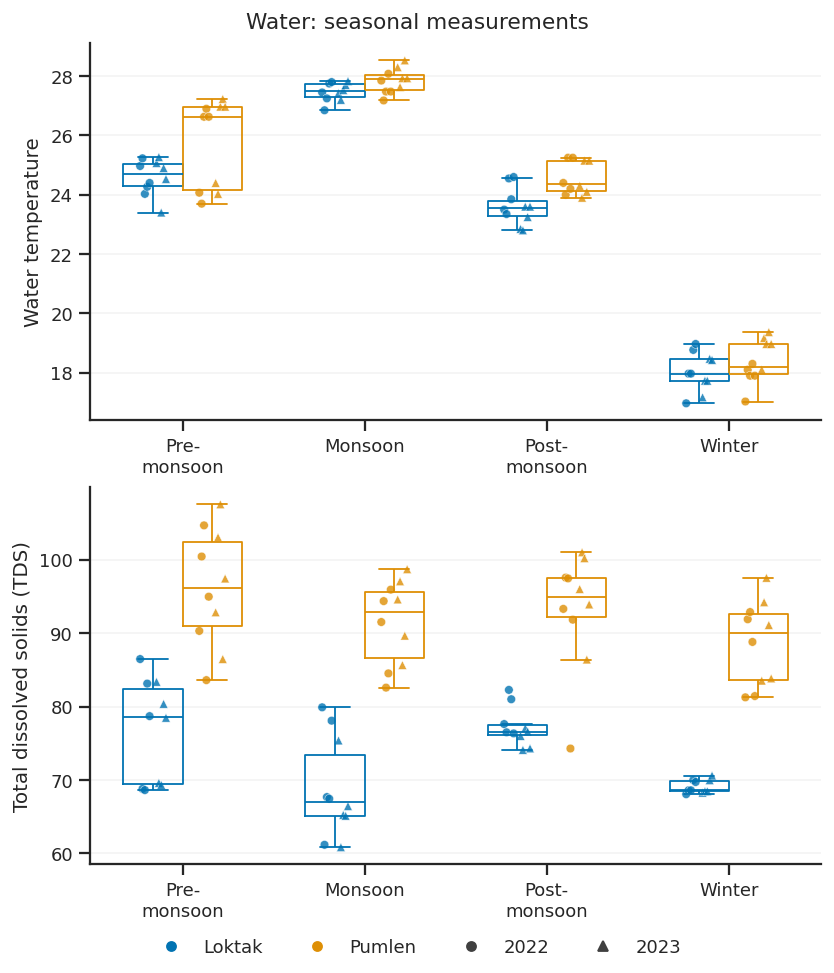

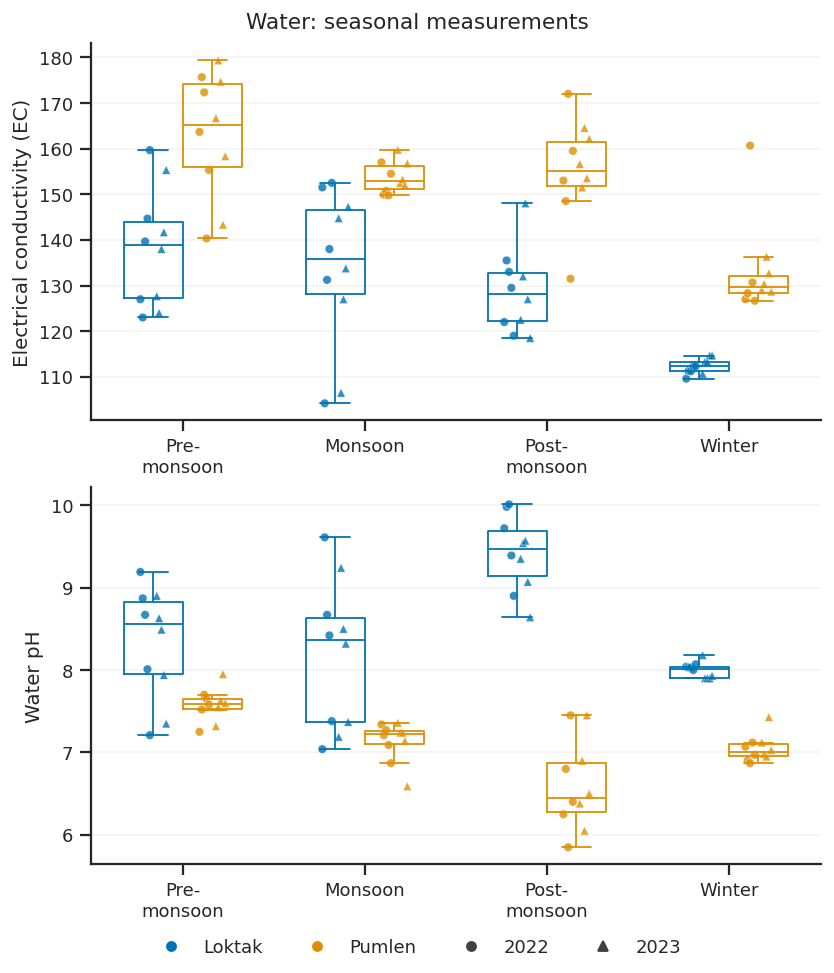

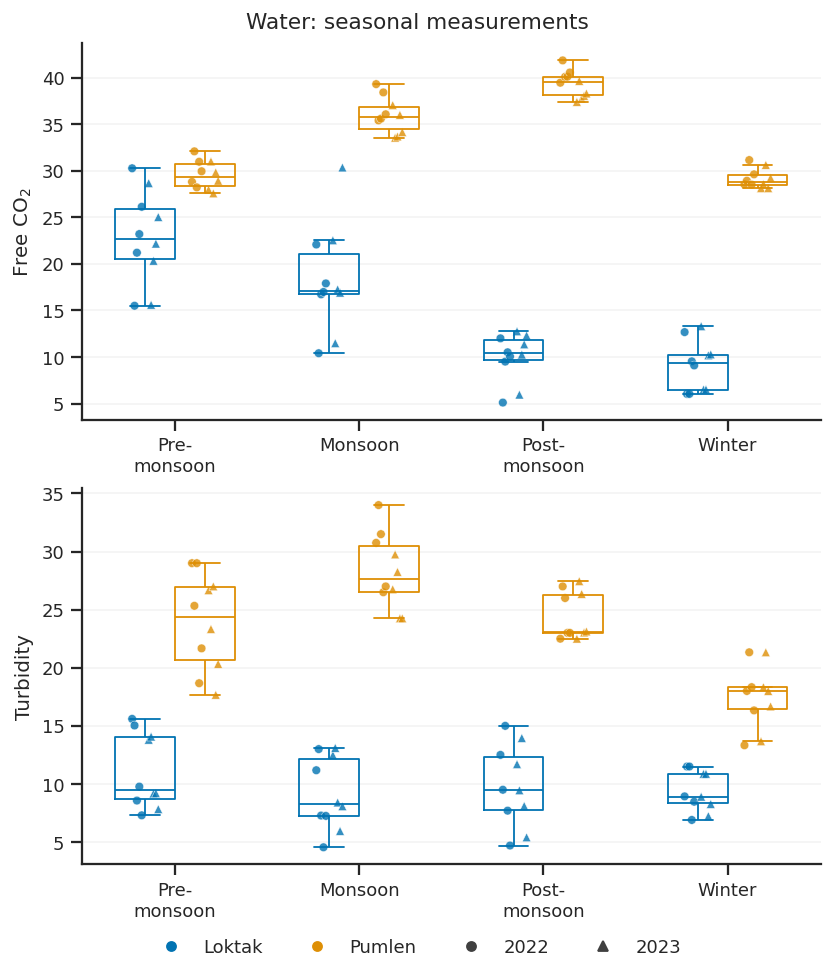

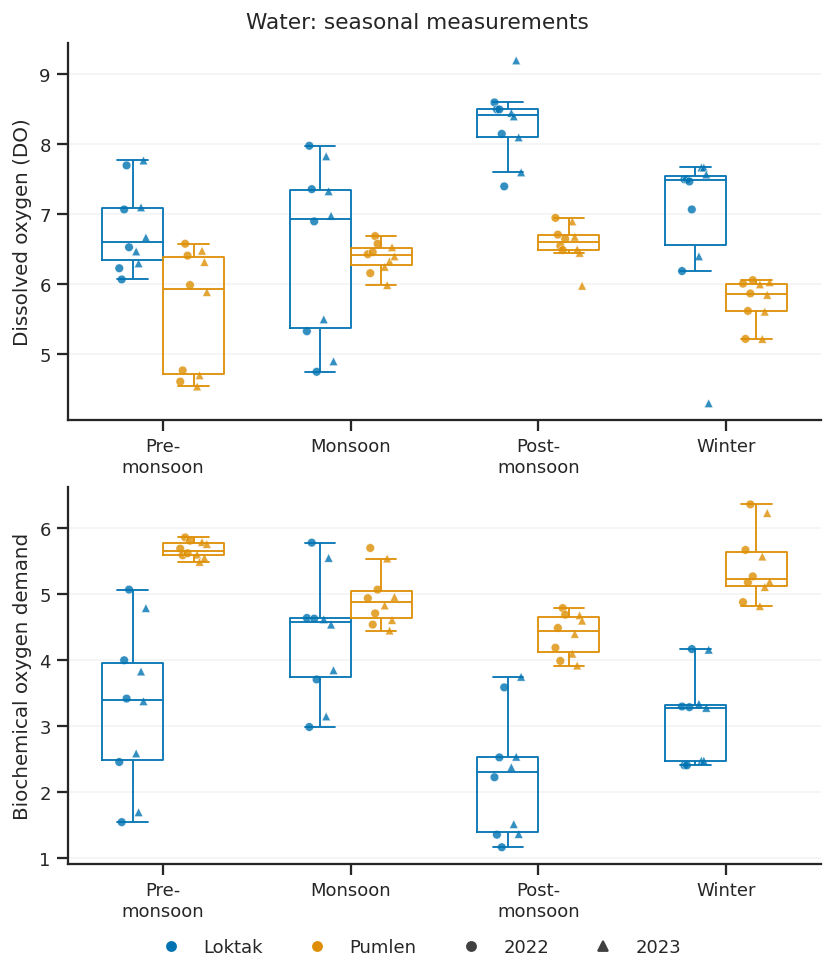

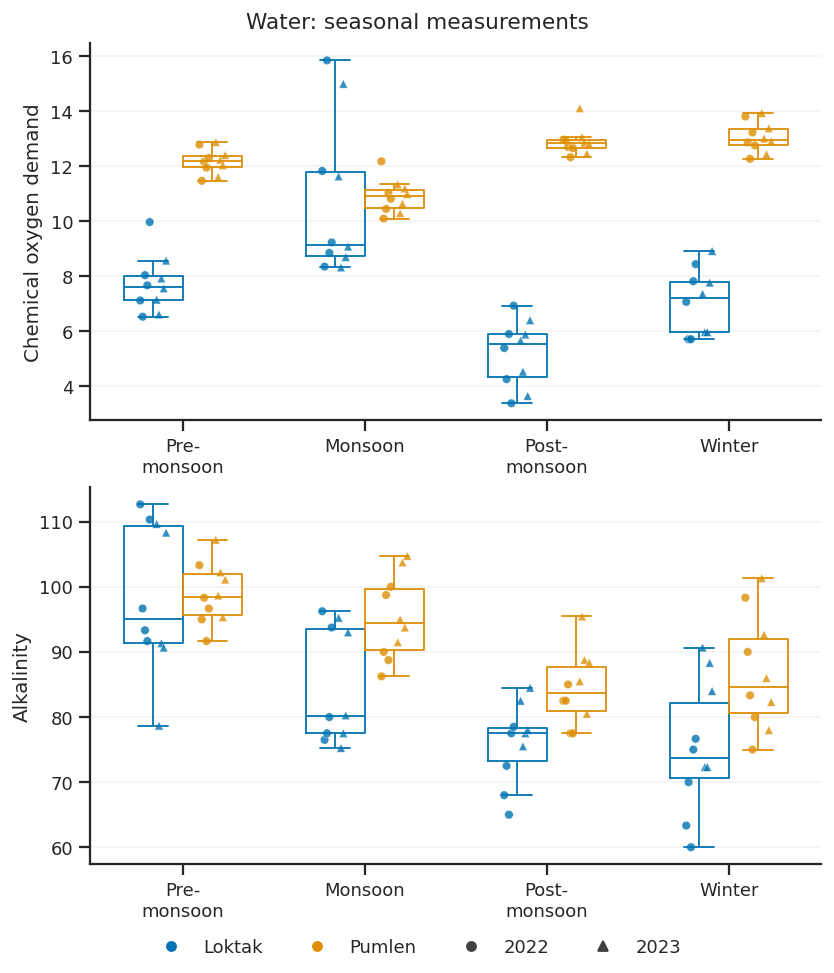

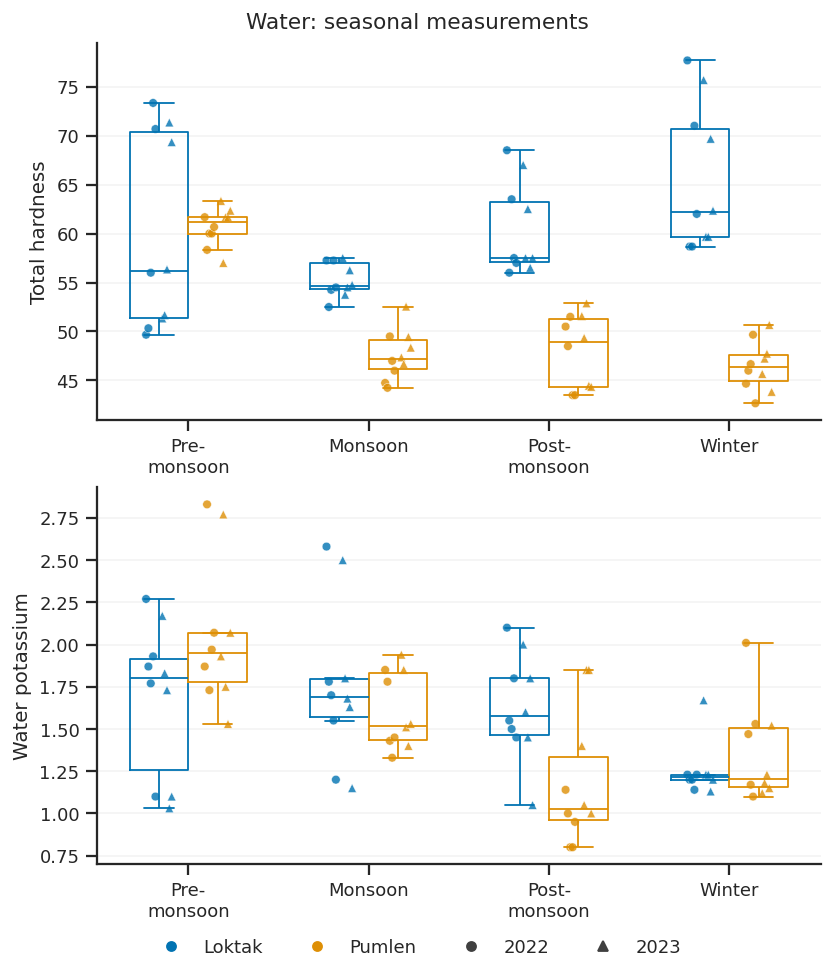

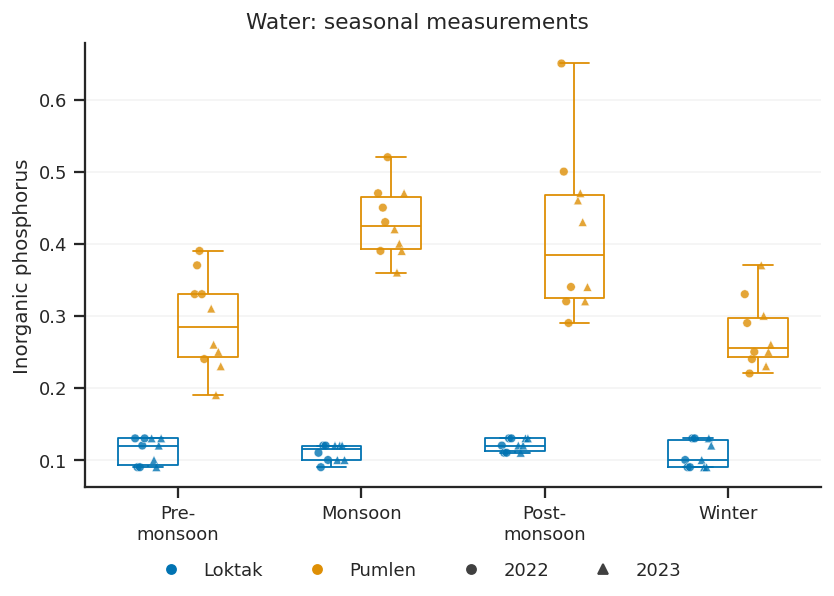

In [4]:
for page,start in enumerate(range(0,len(variables["Water"]),2),1):
    distribution_page("Water", variables["Water"][start:start+2], page)

### What to notice before PCA

In the supplied records, mean water free CO₂ and turbidity are higher in Pumlen,
whereas mean dissolved oxygen and water pH are higher in Loktak. Mean soil SOC,
bulk density and available K are also higher in Loktak. These are descriptive
sample contrasts, combining seasons and years; they do not identify their cause.

The variables have different scales. Standardisation below prevents a variable
from dominating PCA merely because its numerical unit gives it a larger variance.

## 2. PCA definition and scaling

For each compartment, with $n=80$ and $p$ measured variables,
\[
Z_{ij}=\frac{X_{ij}-\bar X_j}{s_j},\quad
s_j^2=\frac{1}{n-1}\sum_i(X_{ij}-\bar X_j)^2,\quad
Z=UDV^{\mathsf T}.
\]
Scores are $T=ZV=UD$, eigenvalues are $\lambda_k=D_{kk}^2/(n-1)$,
and explained fractions are $\lambda_k/\sum_\ell\lambda_\ell$.
Standardisation gives each variable unit sample variance, so $\sum_k\lambda_k=p$.

Here **weights** mean $V_{jk}$; **correlation loadings** mean
$L_{jk}=\mathrm{corr}(Z_j,T_k)=V_{jk}\sqrt{\lambda_k}$.
These are saved separately to avoid conflating conventions. Signs of an entire PC
can reverse without changing the PCA. Correlated inputs (e.g. EC and TDS) remain
included and can give their shared environmental pattern more representation.

In [5]:
results = {}
for name, frame in frames.items():
    X = frame[variables[name]].astype(float)
    means, scales = X.mean(), X.std(ddof=1)
    assert (scales > 0).all()
    Z = (X-means)/scales
    U, singular_values, Vt = np.linalg.svd(Z.to_numpy(), full_matrices=False)
    scores = U * singular_values
    eigenvalues = singular_values**2 / (len(Z)-1)
    explained_fraction = eigenvalues / eigenvalues.sum()
    pcs = [f"PC{k+1}" for k in range(X.shape[1])]
    weights = pd.DataFrame(Vt.T, index=X.columns, columns=pcs)
    loadings = weights.mul(np.sqrt(eigenvalues), axis="columns")
    score_frame = pd.concat([frame[KEYS].reset_index(drop=True),pd.DataFrame(scores,columns=pcs)],axis=1)
    variance = pd.DataFrame({"PC":pcs, "Eigenvalue":eigenvalues,
                             "Explained (%)":100*explained_fraction,
                             "Cumulative (%)":100*np.cumsum(explained_fraction)})
    # Numerical checks: complete PCA reconstructs Z and the loadings are correlations.
    assert np.allclose(scores @ Vt,Z)
    assert np.isclose(eigenvalues.sum(),X.shape[1])
    direct = np.corrcoef(Z.to_numpy().T,scores.T)[:X.shape[1],X.shape[1]:]
    assert np.allclose(loadings,direct)
    results[name] = dict(scores=score_frame,weights=weights,loadings=loadings,variance=variance)
    for suffix,table in [("scores",score_frame),("weights",weights),("correlation_loadings",loadings),
                          ("variance",variance),("standardisation",pd.DataFrame({"Mean":means,"Sample_SD":scales}))]:
        table.to_csv(TABLE_DIR / f"pca_{name.lower()}_{suffix}.csv",index=suffix not in ["scores","variance"])
    print(f"{name}: PC1+PC2 = {variance['Explained (%)'].iloc[:2].sum():.2f}%")
    display(variance.round(3))

Water: PC1+PC2 = 65.44%


,PC,Eigenvalue,Explained (%),Cumulative (%)
0,PC1,6.751,51.927,51.927
1,PC2,1.756,13.509,65.436
2,PC3,1.268,9.754,75.190
3,PC4,0.802,6.171,81.361
4,PC5,0.695,5.345,86.706
5,PC6,0.562,4.324,91.030
6,PC7,0.321,2.467,93.498
7,PC8,0.257,1.980,95.477
8,PC9,0.220,1.695,97.172
9,PC10,0.108,0.830,98.002


Soil: PC1+PC2 = 71.77%


,PC,Eigenvalue,Explained (%),Cumulative (%)
0,PC1,2.807,40.106,40.106
1,PC2,2.216,31.662,71.767
2,PC3,0.965,13.783,85.550
3,PC4,0.435,6.218,91.768
4,PC5,0.282,4.027,95.795
5,PC6,0.233,3.322,99.117
6,PC7,0.062,0.883,100.000


## 3. Explained variance

Bars give the percentage associated with each PC. The cumulative line shows the
percentage retained when successive PCs are included. The first two soil PCs retain
**71.77%** of total standardised variance; the first two water PCs retain **65.44%**.
The remaining variance is not represented in a PC1–PC2 plot.

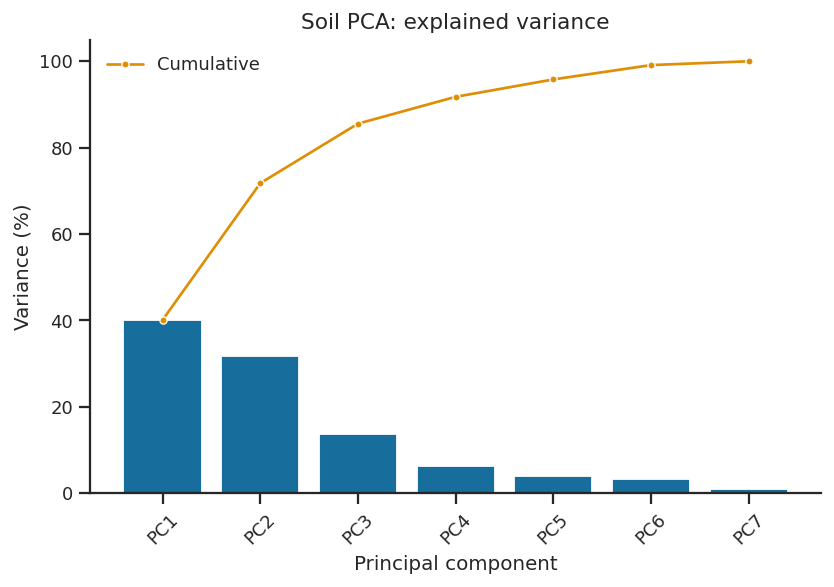

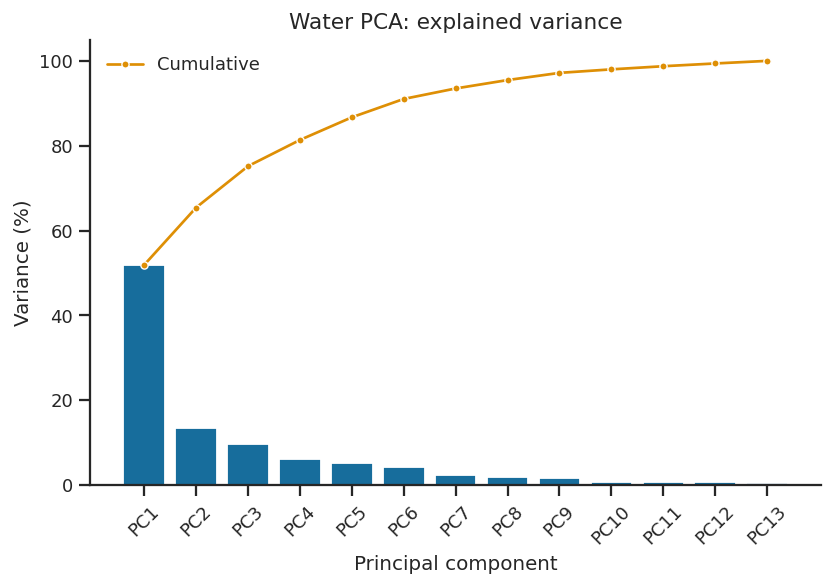

In [6]:
def scree_plot(name):
    variance = results[name]["variance"]
    fig, ax = plt.subplots(figsize=(WIDTH, 4.4), layout="constrained")
    sns.barplot(data=variance, x="PC", y="Explained (%)", color=PALETTE["Loktak"], ax=ax)
    sns.lineplot(x=np.arange(len(variance)), y=variance["Cumulative (%)"].to_numpy(),
                 color=PALETTE["Pumlen"], marker="o", markersize=4, label="Cumulative", ax=ax)
    ax.set(title=f"{name} PCA: explained variance", xlabel="Principal component", ylabel="Variance (%)", ylim=(0,105))
    ax.tick_params(axis="x", rotation=45)
    ax.legend(frameon=False)
    save_show(fig, f"pca_{name.lower()}_scree",
              f"{name} PCA of sample-SD-standardised measurements: variance explained by each component (bars) and cumulative percentage (line). All measured variables in this compartment are retained. Identifiers are excluded.")

scree_plot("Soil")
scree_plot("Water")

## 4. Scores: observations projected onto PC1–PC2

Colour identifies lake, shape identifies season. Each point is one site–season–year
record. Axis percentages give explained variance. Distances refer only to this
two-component projection. Equal aspect ratios preserve its geometry.

Each year-specific figure uses the **same PCA fitted to all 80 records**, with the
same x and y limits. The PCA is not refitted separately to each year.

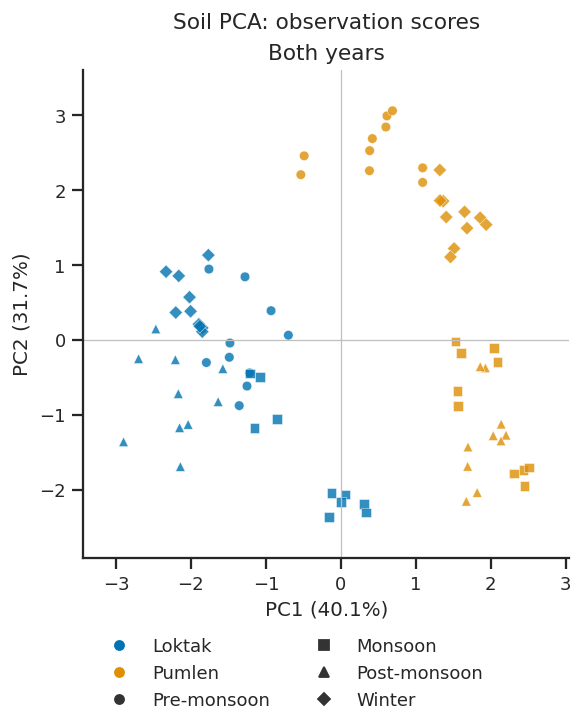

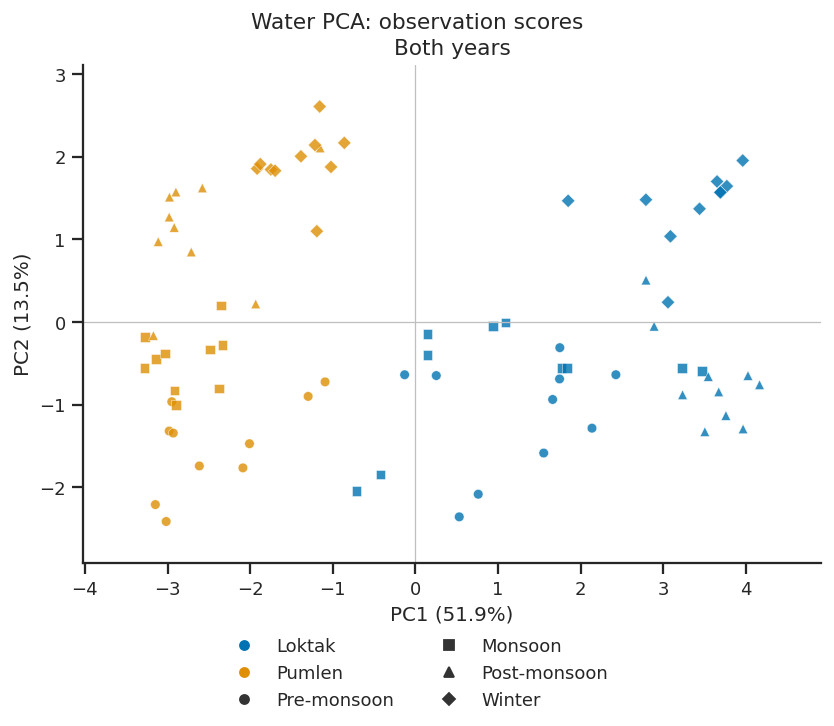

In [7]:
def score_plot(name, by_year=False):
    result = results[name]
    scores = result["scores"]
    pc1,pc2 = result["variance"]["Explained (%)"].iloc[:2]
    groups = [2022,2023] if by_year else [None]
    fig, axes = plt.subplots(len(groups), 1, figsize=(WIDTH, 8.2 if by_year else 5.5),
                             squeeze=False, layout="constrained")
    limits = {}
    for pc in ["PC1","PC2"]:
        lo,hi = scores[pc].min(),scores[pc].max()
        limits[pc] = (lo-0.1*(hi-lo), hi+0.1*(hi-lo))
    for ax,year in zip(axes.flat,groups):
        subset = scores if year is None else scores.query("Year == @year")
        sns.scatterplot(data=subset, x="PC1", y="PC2", hue="Wetland", style="Season",
                        hue_order=WETLANDS, style_order=SEASONS, palette=PALETTE,
                        markers=MARKERS, s=28, alpha=0.8, edgecolor="white", linewidth=0.3,
                        legend=False, ax=ax)
        ax.axhline(0,color="0.75",lw=0.7); ax.axvline(0,color="0.75",lw=0.7)
        ax.set(xlabel=f"PC1 ({pc1:.1f}%)", ylabel=f"PC2 ({pc2:.1f}%)",
               xlim=limits["PC1"], ylim=limits["PC2"], title=str(year) if year else "Both years")
        ax.set_aspect("equal", adjustable="box")
    fig.legend(handles=lake_handles()+season_handles(), loc="outside lower center", ncol=2, frameon=False)
    fig.suptitle(f"{name} PCA: observation scores", fontsize=12)
    save_show(fig, f"pca_{name.lower()}_scores" + ("_by_year" if by_year else ""),
              f"{name} PCA scores for PC1 and PC2, with lake colours and season symbols. Both components are obtained from the same PCA of all 80 records. "
              + ("Year panels share limits and preserve equal x/y scale. " if by_year else "Both years are pooled; coincident observations may overlap. ")
              + "The plot is descriptive and does not test separation between groups.")

score_plot("Soil")
score_plot("Water")

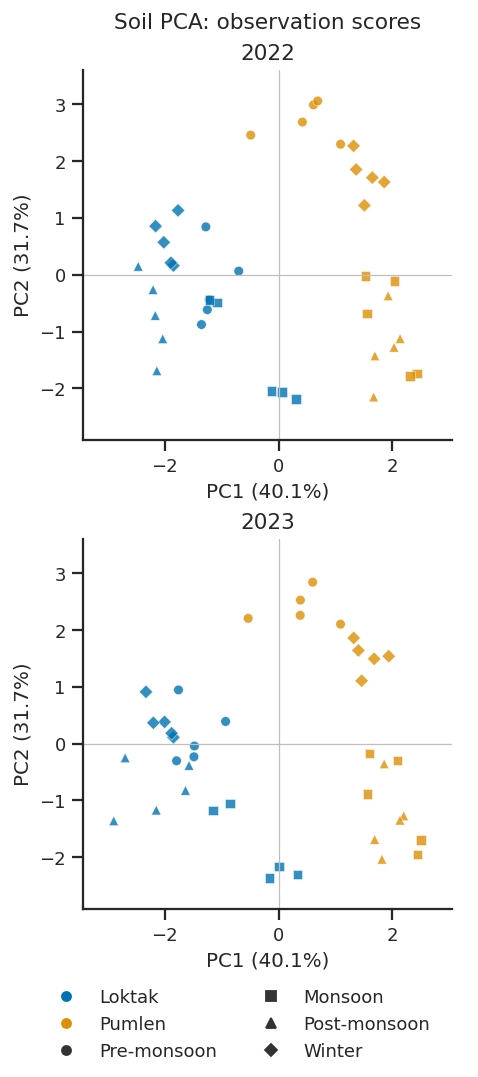

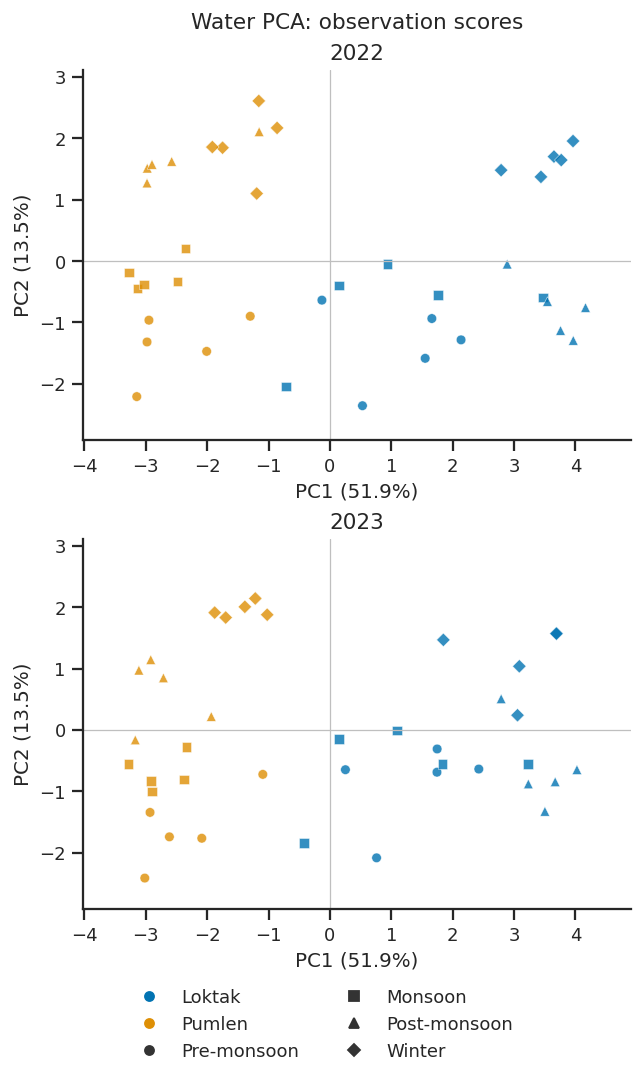

In [8]:
score_plot("Soil", by_year=True)
score_plot("Water", by_year=True)

## 5. Loadings: which variables define the components?

These figures show **correlation loadings** $L_{jk}=\mathrm{corr}(Z_j,T_k)$ for every
variable and the first four PCs. Scores and loadings have separate figures, so raw
score coordinates are not mixed with arbitrarily scaled correlation arrows.
No variables are selected or omitted from the PCA or loading figures.

The sign of a PC is arbitrary: reversing a component reverses both its scores and
loadings. Relative signs and loading magnitudes are meaningful. The exported tables
also contain weights, all PCs, and the means/SDs used for standardisation.

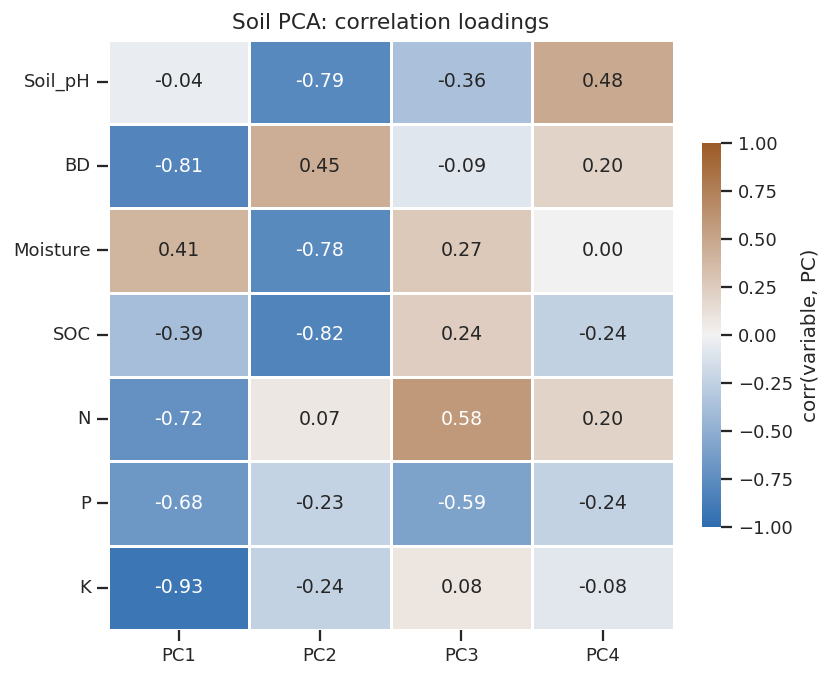

,Variance fraction represented in PC1-PC2
Soil_pH,0.622
BD,0.854
Moisture,0.770
SOC,0.823
N,0.530
P,0.511
K,0.913


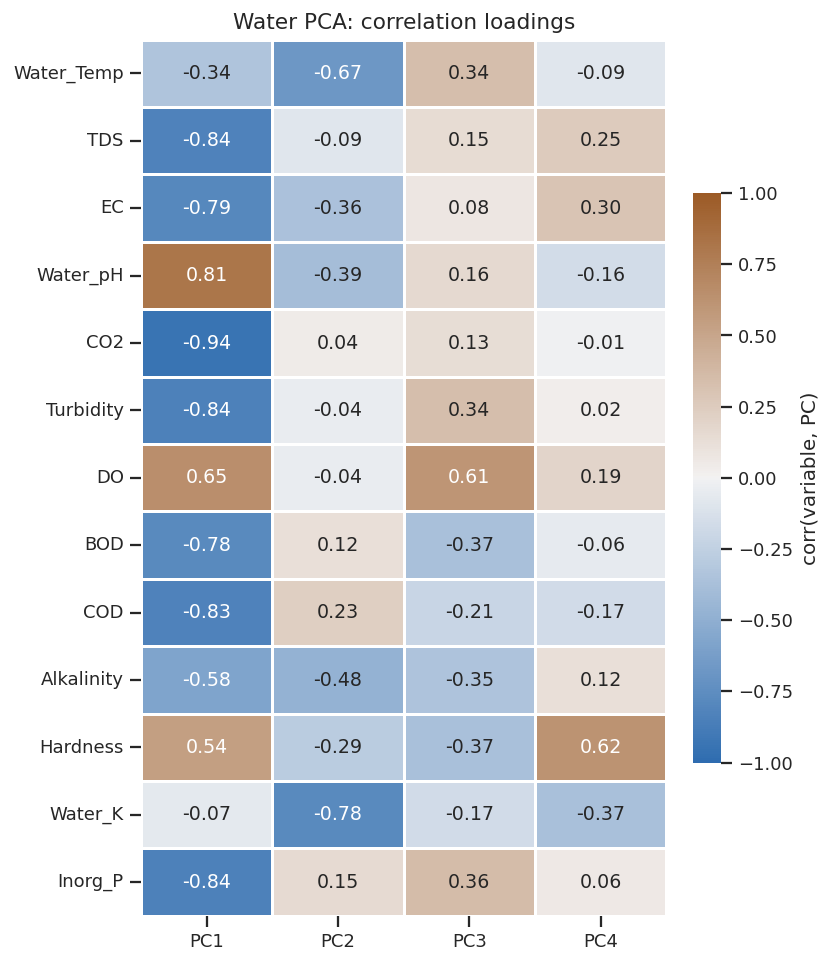

,Variance fraction represented in PC1-PC2
Water_Temp,0.566
TDS,0.706
EC,0.764
Water_pH,0.815
CO2,0.881
Turbidity,0.703
DO,0.425
BOD,0.617
COD,0.749
Alkalinity,0.567


In [9]:
for name in ["Soil","Water"]:
    loadings = results[name]["loadings"]
    fig, ax = plt.subplots(figsize=(WIDTH, 5.1 if name == "Soil" else 7.3), layout="constrained")
    sns.heatmap(loadings.iloc[:,:4], cmap=sns.diverging_palette(250,35,s=85,l=45,as_cmap=True),
                vmin=-1,vmax=1,center=0,annot=True,fmt=".2f",annot_kws={"fontsize":10.5},
                linewidths=0.6,cbar_kws={"label":"corr(variable, PC)","shrink":0.65},ax=ax)
    ax.set(title=f"{name} PCA: correlation loadings", xlabel="", ylabel="")
    ax.tick_params(axis="y",rotation=0)
    save_show(fig, f"pca_{name.lower()}_loadings",
              f"Correlation between each standardised {name.lower()} variable and PC1-PC4. All variables are shown; raw workbook column names identify them. The same fixed -1 to +1 colour scale is used throughout. Signs of entire PCs may reverse without changing the PCA.")
    display(loadings[["PC1","PC2"]].pow(2).sum(axis=1).rename(
        "Variance fraction represented in PC1-PC2").to_frame().round(3))

## Conclusions for these data

**Soil:** PC1 and PC2 explain **40.11%** and **31.66%** of standardised variance.
PC1 has large absolute correlations with available K (**0.926**), bulk density
(**0.806**) and available N (**0.725**). PC2 is associated with SOC (**0.820**),
soil pH (**0.788**) and moisture (**0.778**) in absolute value. This separates
several covarying soil characteristics rather than identifying independent drivers.

**Water:** PC1 explains **51.93%**, and PC2 **13.51%**. PC1 contrasts water pH and
dissolved oxygen with a group including free CO₂, TDS, turbidity, COD and inorganic P.
PC2 has its largest absolute correlations with water K (**0.776**) and temperature
(**0.673**). Read their directions from the signed loading table.

The score plots show a substantial lake contrast along PC1 in both compartments,
with additional seasonal structure. The same basis applied to both years makes the
year panels directly comparable. These patterns describe the observed covariance;
they do not demonstrate environmental effects on carbon storage or test effects of
disturbance. Correlated inputs remain in the PCA, so clusters of related measurements
can carry more weight than a process represented by only one variable.